Environment Setup


In [43]:
!pip install "wfdb>=4.1" "numpy>=1.26" "pandas>=2.0"

In [44]:
import os
import wfdb
import numpy as np
from tqdm import tqdm
import pandas as pd
import random
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("wfdb:", wfdb.__version__)

def set_seed(seed=42):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pandas: 3.0.1
numpy: 2.0.2
wfdb: 4.3.1


Data Preprocessing

In [45]:
# Upload dataset
DATA_DIR = "/content/drive/MyDrive/MIT_BIT_DATASET"

assert os.path.exists(DATA_DIR), "Dataset path does not exist"
print("Dataset folder found")
print("Sample files:", os.listdir(DATA_DIR)[:10])


Dataset folder found
Sample files: ['102.hea', '116.hea', '114.hea', '113.hea', '113.atr', '113.dat', '104.dat', '119.atr', '118.atr', '109.hea']


In [46]:
# Get valid records
def get_valid_records(data_dir):
    files = os.listdir(data_dir)
    records = set(f.split('.')[0] for f in files)

    valid = []
    for r in records:
        if (f"{r}.dat" in files and
            f"{r}.hea" in files and
            f"{r}.atr" in files):
            valid.append(r)

    return sorted(valid)

records = get_valid_records(DATA_DIR)

print(f"Found {len(records)} valid records")
print("First 10 records:", records[:10])


Found 48 valid records
First 10 records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']


In [47]:
# Feature Engineering
# Valid heartbeat symbols
valid_symbols = {
    'N','L','R',
    'A','a','J','j','S',
    'V','E',
    'F','f',
    'Q'
}

# AAMI EC57 mapping
aami_map = {
    'N':'N', 'L':'N', 'R':'N',
    'A':'S', 'a':'S', 'J':'S', 'j':'S', 'S':'S',
    'V':'V', 'E':'V',
    'F':'F', 'f':'F',
    'Q':'Q'
}

FS = 360
WINDOW_SEC = 0.6
WINDOW = int(FS * WINDOW_SEC)
HALF_WINDOW = WINDOW // 2

X, y, groups = [], [], []

# Store discarded beats for inspection
discarded_X = []
discarded_y = []

for rec in tqdm(records):
    try:
        rec_path = os.path.join(DATA_DIR, rec)

        record = wfdb.rdrecord(rec_path)
        ann = wfdb.rdann(rec_path, 'atr')

        signal = record.p_signal[:, 0]  # MLII lead

        for r, label in zip(ann.sample, ann.symbol):

            # Boundary check
            if r - HALF_WINDOW < 0 or r + HALF_WINDOW > len(signal):
                continue

            beat = signal[r - HALF_WINDOW : r + HALF_WINDOW]

            # ---- FILTERING LOGIC ----
            if label in valid_symbols:
                X.append(beat)
                y.append(aami_map[label])   # map to AAMI class
                groups.append(rec)
            else:
                discarded_X.append(beat)
                discarded_y.append(label)

    except Exception as e:
        print(f"Skipping record {rec}: {e}")



100%|██████████| 48/48 [00:04<00:00, 10.58it/s]


In [48]:
X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

discarded_X = np.array(discarded_X, dtype=np.float32)
discarded_y = np.array(discarded_y)

print("Final dataset shape:")
print("X:", X.shape)
print("y:", y.shape)
print("Groups:", groups.shape)

print("\nAAMI class distribution:")
print(dict(zip(*np.unique(y, return_counts=True))))

print("\nDiscarded labels (sample):")
print(np.unique(discarded_y))

Final dataset shape:
X: (102420, 216)
y: (102420,)
Groups: (102420,)

AAMI class distribution:
{np.str_('F'): np.int64(1784), np.str_('N'): np.int64(90358), np.str_('Q'): np.int64(33), np.str_('S'): np.int64(3010), np.str_('V'): np.int64(7235)}

Discarded labels (sample):
['!' '"' '+' '/' '[' ']' 'e' 'x' '|' '~']


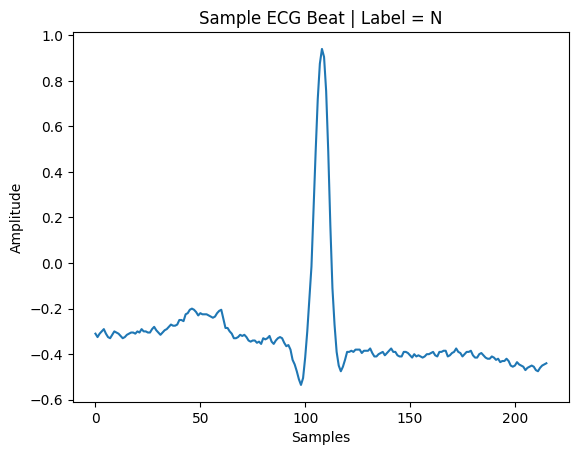

In [49]:
# Plot sample heartbeat
plt.plot(X[0])
plt.title(f"Sample ECG Beat | Label = {y[0]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


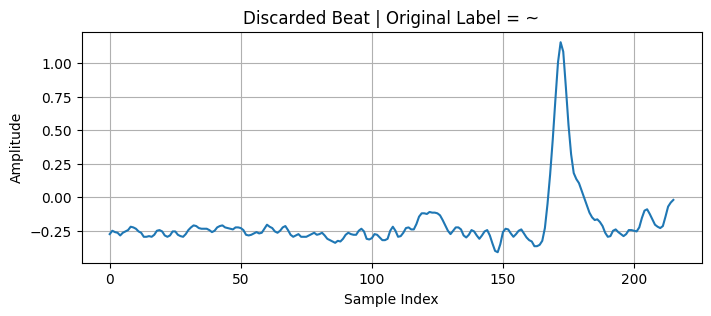

In [50]:
# Plot discarded heartbeat

idx = 0

plt.figure(figsize=(8, 3))
plt.plot(discarded_X[idx])
plt.title(f"Discarded Beat | Original Label = {discarded_y[idx]}")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [51]:
# Removing Q
# Create mask for non-Q samples
mask = y != 'Q'

# Apply mask
X_filtered = X[mask]
y_filtered = y[mask]
groups_filtered = groups[mask]

print("After dropping Q:")
print(Counter(y_filtered))

print("Shapes after filtering:")
print("X:", X_filtered.shape)
print("y:", y_filtered.shape)
print("groups:", groups_filtered.shape)

After dropping Q:
Counter({np.str_('N'): 90358, np.str_('V'): 7235, np.str_('S'): 3010, np.str_('F'): 1784})
Shapes after filtering:
X: (102387, 216)
y: (102387,)
groups: (102387,)


In [52]:
# Encoding the labels
label_map = {
    'N': 0,
    'S': 1,
    'V': 2,
    'F': 3
}

y_encoded = np.array([label_map[label] for label in y_filtered])

In [53]:
# Train-Test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X_filtered, y_encoded, groups_filtered):

    X_train, X_test = X_filtered[train_idx], X_filtered[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    groups_train = groups_filtered[train_idx]
    groups_test  = groups_filtered[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, val_idx = next(
    gss_val.split(X_train, y_train, groups_train)
)

X_train_final = X_train[train_idx]
y_train_final = y_train[train_idx]
groups_train_final = groups_train[train_idx]

X_val = X_train[val_idx]
y_val = y_train[val_idx]
groups_val = groups_train[val_idx]


In [54]:
print(set(groups_train_final) & set(groups_val))  # should be empty
print(set(groups_train_final) & set(groups_test)) # should be empty
print(set(groups_val) & set(groups_test))         # should be empty

set()
set()
set()


Model

In [55]:
# Model
class ECGModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        x = torch.mean(x, dim=2)  # Global Average Pooling

        x = self.fc(x)
        return x

Training

In [56]:
# Converting to Tensor
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32).reshape(-1,1,216)
y_train_tensor = torch.tensor(y_train_final, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32).reshape(-1,1,216)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).reshape(-1,1,216)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [57]:
# Create Weighted Random Sampler for Training Dataset

# Count samples per class
class_counts = np.bincount(y_train_final)

# Inverse frequency
class_weights = 1.0 / class_counts

# Assign weight to each sample
sample_weights = class_weights[y_train_final]

# Convert to tensor
sample_weights = torch.tensor(sample_weights, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [58]:
BATCH_SIZE = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler,
    shuffle=False   # MUST be False when using sampler
)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [59]:
# Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ECGModel(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay = 1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # because we monitor val_loss
    factor=0.5,        # reduce LR by half
    patience=2         # wait 2 epochs before reducing
)

In [60]:
# Training
NUM_EPOCHS = 30
best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(NUM_EPOCHS):

    # ---------------------
    # TRAINING
    # ---------------------
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # ---------------------
    # VALIDATION
    # ---------------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            # Get predicted class
            preds = torch.argmax(outputs, dim=1)

            # Count correct predictions
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = correct / total
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"LR: {current_lr:.6f} "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_accuracy:.4f}")

    # ---------------------
    # EARLY STOPPING
    # ---------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch [1/30] LR: 0.000500 Train Loss: 0.5165 Val Loss: 1.0441 Val Acc: 0.6824
Epoch [2/30] LR: 0.000500 Train Loss: 0.3040 Val Loss: 1.5890 Val Acc: 0.4604
Epoch [3/30] LR: 0.000500 Train Loss: 0.2407 Val Loss: 0.5962 Val Acc: 0.8054
Epoch [4/30] LR: 0.000500 Train Loss: 0.2111 Val Loss: 1.0257 Val Acc: 0.6629
Epoch [5/30] LR: 0.000500 Train Loss: 0.1925 Val Loss: 2.9401 Val Acc: 0.3496
Epoch [6/30] LR: 0.000250 Train Loss: 0.1766 Val Loss: 0.7798 Val Acc: 0.7470
Epoch [7/30] LR: 0.000250 Train Loss: 0.1468 Val Loss: 1.3653 Val Acc: 0.5712
Epoch [8/30] LR: 0.000250 Train Loss: 0.1445 Val Loss: 1.4054 Val Acc: 0.6384
Early stopping triggered.


In [61]:
# Load best Model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

ECGModel(
  (conv_block1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

Testing and Evaluation

In [62]:
# Testing
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average=None)
recall = recall_score(all_labels, all_preds, average=None)
f1 = f1_score(all_labels, all_preds, average=None)
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("\nOverall Accuracy:", accuracy)
print("Macro F1 Score:", macro_f1)

for i in range(4):
    print(f"\nClass {i}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall:    {recall[i]:.4f}")
    print(f"F1 Score:  {f1[i]:.4f}")



Overall Accuracy: 0.7296413851911507
Macro F1 Score: 0.602617049711459

Class 0:
Precision: 0.9455
Recall:    0.7456
F1 Score:  0.8337

Class 1:
Precision: 0.0345
Recall:    0.2559
F1 Score:  0.0608

Class 2:
Precision: 0.6076
Recall:    0.6562
F1 Score:  0.6310

Class 3:
Precision: 0.9719
Recall:    0.8123
F1 Score:  0.8850


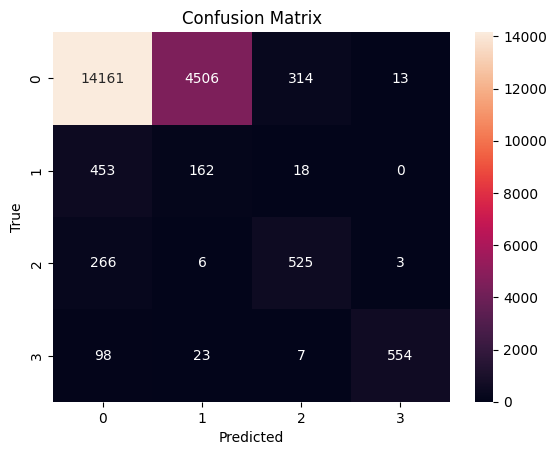

In [63]:
# Print Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
